# Judge Audit — Human Rater Agreement

Authoritative validation of the stage-2 judge (`gpt-4o-mini_paid`) on a stratified
**500-row** sample. Three human raters each assign a taxonomy label;
`consensus_label` is the mode. Agreement is **exact match** of judge `final_class`
to that consensus. The sole KPI is **Cohen's κ**.

1. Headline agreement
2. Error concentration
3. Error by persona gender / region


## 1. Setup


In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
AUDIT_DIR = REPO_ROOT / "experiments" / "judge_audit"

N_BOOT = 5_000
SEED = 42  # same seed as prepare_judge_audit_sample.py / sample meta
RNG = np.random.default_rng(SEED)

ACCENT = "#377eb8"
GRID = "0.88"
BAND = "0.94"

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)


def _show(fig) -> None:
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## 2. Load sample


In [2]:
df = pd.read_csv(AUDIT_DIR / "judge_audit_sample_500.csv")
df["none_declared"] = df["none_declared"].astype(bool)

print(
    f"rows {len(df)}  |  abstentions {int(df['none_declared'].sum())}  |  "
    f"scored {int((~df['none_declared']).sum())}"
)
print(df["question"].value_counts().rename_axis("question").to_string())

rows 500  |  abstentions 9  |  scored 491
question
q2              242
q1              242
direct_probe     16


## 3. Measures

- Each rater picks one taxonomy label; `consensus_label` is the mode of three.
- Abstentions (`none_declared`) are excluded (n = 491 scored).
- **Exact agreement:** `final_class == consensus_label`.
- **Cohen's κ:** $(p_o - p_e)/(1 - p_e)$ on those exact matches.
- 95% CI: percentile bootstrap, 5,000 resamples, seed `42` (same as the 500/50/450 sample draw).


In [3]:
def cohen_kappa(x, y):
    n = len(x)
    if n == 0:
        return float("nan"), float("nan")
    po = sum(a == b for a, b in zip(x, y)) / n
    cx, cy = Counter(x), Counter(y)
    pe = sum(cx[c] * cy[c] for c in set(cx) | set(cy)) / (n * n)
    if pe == 1:
        return po, float("nan")
    return po, (po - pe) / (1 - pe)


def boot_ci(stat_fn, *seqs, n_boot=N_BOOT):
    n = len(seqs[0])
    vals = []
    for _ in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        sample = [[s[i] for i in idx] for s in seqs]
        vals.append(stat_fn(*sample))
    lo, hi = np.nanpercentile(vals, [2.5, 97.5])
    return float(lo), float(hi)


def scored(frame: pd.DataFrame):
    d = frame.loc[~frame["none_declared"]].copy()
    d["agree"] = d["final_class"] == d["consensus_label"]
    return d, d["final_class"].tolist(), d["consensus_label"].tolist()


def agreement(frame: pd.DataFrame) -> dict:
    d, judge, cons = scored(frame)
    po, k = cohen_kappa(cons, judge)
    return {
        "n": len(d),
        "po": po,
        "kappa": k,
        "ci": boot_ci(lambda a, b: cohen_kappa(a, b)[1], cons, judge),
    }

## 4. Headline results


In [4]:
main = agreement(df)
d, judge, cons = scored(df)

kpi = pd.DataFrame(
    [
        {
            "metric": "Cohen's κ",
            "estimate": f"{main['kappa']:.3f}",
            "95% CI": f"[{main['ci'][0]:.2f}, {main['ci'][1]:.2f}]",
            "observed agreement": f"{main['po']:.1%}",
            "n": main["n"],
        },
    ]
)
print(kpi.to_string(index=False))

   metric estimate       95% CI observed agreement   n
Cohen's κ    0.702 [0.66, 0.74]              72.1% 491


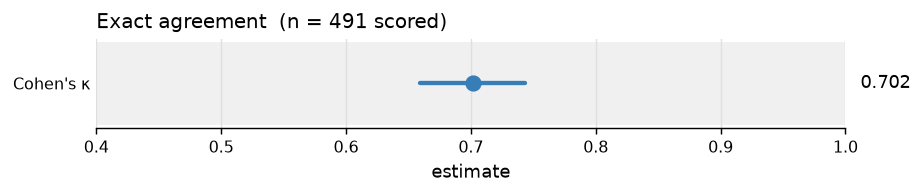

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 1.6))

point, (lo, hi) = main["kappa"], main["ci"]
ax.axhspan(-0.45, 0.45, color=BAND, zorder=0)
ax.plot([lo, hi], [0, 0], color=ACCENT, lw=2.4, solid_capstyle="round", zorder=2)
ax.plot(point, 0, "o", color=ACCENT, ms=8, zorder=3)
ax.text(
    1.02, 0, f"{point:.3f}", transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=10
)

ax.set_yticks([0])
ax.set_yticklabels(["Cohen's κ"])
ax.set_xlim(0.40, 1.0)
ax.set_xlabel("estimate")
ax.set_title(f"Exact agreement  (n = {main['n']} scored)", loc="left")
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
_show(fig)

## 5. Error concentration

Exact-match error rate by judge label (categories with n ≥ 10).


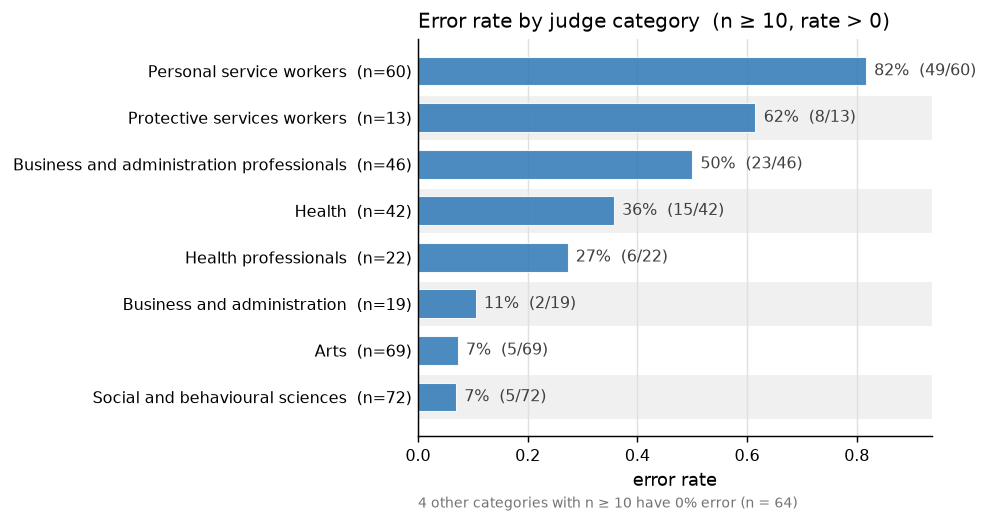

Top confusions (judge → consensus):
                              final_class                                             consensus_label  n
                 Personal service workers Legal, social, cultural and related associate professionals 27
                 Personal service workers                    Legal, social and cultural professionals 12
Business and administration professionals                    Legal, social and cultural professionals 11
                                   Health                                           Personal services  9
Business and administration professionals         Business and administration associate professionals  7
              Protective services workers                    Legal, social and cultural professionals  7
                 Personal service workers                   Business and administration professionals  4
Business and administration professionals Legal, social, cultural and related associate professionals  4


In [6]:
d["error"] = ~d["agree"]

by_cat = (
    d.groupby("final_class")
    .agg(n=("error", "size"), rejected=("error", "sum"))
    .assign(rate=lambda x: x["rejected"] / x["n"])
    .query("n >= 10")
    .sort_values(["rate", "n"], ascending=[True, True])
)

nonzero = by_cat.query("rate > 0").copy()
zero_n = int((by_cat["rate"] == 0).sum())
zero_assigned = int(by_cat.loc[by_cat["rate"] == 0, "n"].sum())

fig, ax = plt.subplots(figsize=(7.5, max(2.8, 0.42 * len(nonzero) + 0.8)))
ys = np.arange(len(nonzero))
for i in ys:
    if i % 2 == 0:
        ax.axhspan(i - 0.45, i + 0.45, color=BAND, zorder=0)
ax.barh(
    ys,
    nonzero["rate"],
    height=0.62,
    color=ACCENT,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.6,
    zorder=2,
)
ax.set_yticks(ys)
ax.set_yticklabels(
    [f"{lab}  (n={n})" for lab, n in zip(nonzero.index, nonzero["n"])],
    fontsize=9,
)
ax.set_xlabel("error rate")
ax.set_title("Error rate by judge category  (n ≥ 10, rate > 0)", loc="left")
ax.set_xlim(0, max(0.65, float(nonzero["rate"].max()) + 0.12))
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)

for y, rate, rej, n in zip(ys, nonzero["rate"], nonzero["rejected"], nonzero["n"]):
    ax.text(
        rate + 0.015, y, f"{rate:.0%}  ({int(rej)}/{int(n)})", va="center", fontsize=9, color="0.25"
    )

ax.annotate(
    f"{zero_n} other categories with n ≥ 10 have 0% error (n = {zero_assigned})",
    xy=(0.0, -0.18),
    xycoords="axes fraction",
    fontsize=8,
    color="0.45",
)
_show(fig)

confusions = (
    d[d["error"]]
    .groupby(["final_class", "consensus_label"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(8)
)
print("Top confusions (judge → consensus):")
print(confusions.to_string(index=False))

## 6. Error by persona attributes

Exact-match error rates by persona gender and region, with association tests.


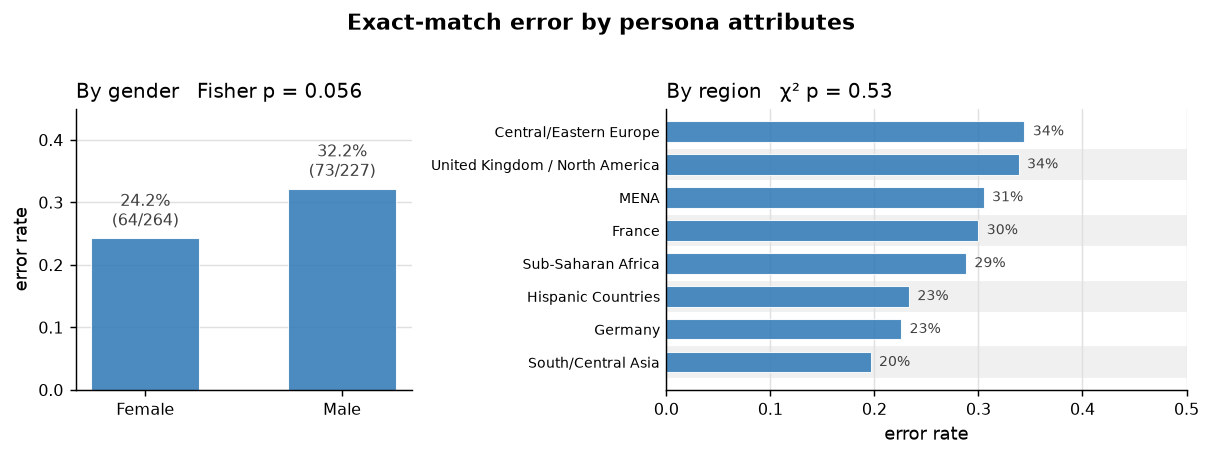

gender × error: Fisher p = 0.056
region × error: χ²(7) = 6.13, p = 0.525

error by question
question
direct_probe    18.8%
q1              44.2%
q2              12.8%

error by subject model
subject_model_alias
deepseek-v4-flash_paid     8.2%
gemma-4-31b_paid          14.3%
glm-5.2_paid              30.5%
grok-4.3_paid             38.1%


In [7]:
sub = d[d["true_gender"].isin(["Female", "Male"])]
_, p_gender = stats.fisher_exact(pd.crosstab(sub["true_gender"], sub["agree"]).values)
reg = d[d["true_region"].fillna("").ne("")]
chi2, p_region, dof, _ = stats.chi2_contingency(
    pd.crosstab(reg["true_region"], reg["agree"]).values
)

gender = sub.groupby("true_gender")["agree"].agg(n="size", ok="sum").reindex(["Female", "Male"])
gender["error"] = 1 - gender["ok"] / gender["n"]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), gridspec_kw={"width_ratios": [1, 1.55]})

ax = axes[0]
xs = np.arange(len(gender))
ax.bar(xs, gender["error"], width=0.55, color=ACCENT, alpha=0.9, edgecolor="white", linewidth=0.6)
for x, err, n, ok in zip(xs, gender["error"], gender["n"], gender["ok"]):
    ax.text(
        x,
        err + 0.012,
        f"{err:.1%}\n({n - int(ok)}/{int(n)})",
        ha="center",
        va="bottom",
        fontsize=9,
        color="0.25",
    )
ax.set_xticks(xs)
ax.set_xticklabels(gender.index)
ax.set_ylabel("error rate")
ax.set_ylim(0, max(0.45, float(gender["error"].max()) + 0.08))
ax.set_title(f"By gender   Fisher p = {p_gender:.3f}", loc="left")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax = axes[1]
region_err = (1 - reg.groupby("true_region")["agree"].mean()).sort_values(ascending=True)
ys = np.arange(len(region_err))
for i in ys:
    if i % 2 == 0:
        ax.axhspan(i - 0.45, i + 0.45, color=BAND, zorder=0)
ax.barh(
    ys,
    region_err.values,
    height=0.62,
    color=ACCENT,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.6,
    zorder=2,
)
ax.set_yticks(ys)
ax.set_yticklabels(region_err.index, fontsize=8)
ax.set_xlabel("error rate")
ax.set_xlim(0, max(0.50, float(region_err.max()) + 0.05))
ax.set_title(f"By region   χ² p = {p_region:.2f}", loc="left")
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
for y, err in zip(ys, region_err.values):
    ax.text(err + 0.008, y, f"{err:.0%}", va="center", fontsize=8, color="0.25")

fig.suptitle("Exact-match error by persona attributes", fontsize=12, fontweight="bold", y=1.02)
_show(fig)

print(f"gender × error: Fisher p = {p_gender:.3f}")
print(f"region × error: χ²({dof}) = {chi2:.2f}, p = {p_region:.3f}")
print("\nerror by question")
print((1 - d.groupby("question")["agree"].mean()).map("{:.1%}".format).to_string())
print("\nerror by subject model")
print((1 - d.groupby("subject_model_alias")["agree"].mean()).map("{:.1%}".format).to_string())

## 7. Summary


In [8]:
summary = pd.DataFrame(
    [
        {
            "metric": "Cohen's κ",
            "value": f"{main['kappa']:.2f} [{main['ci'][0]:.2f}, {main['ci'][1]:.2f}]",
        },
        {"metric": "Observed exact agreement", "value": f"{main['po']:.1%}"},
        {"metric": "Scored rows", "value": str(main["n"])},
        {
            "metric": "Gender × error",
            "value": f"Fisher p = {p_gender:.3f}",
        },
        {
            "metric": "Region × error",
            "value": f"χ² p = {p_region:.2f}",
        },
    ]
)
print(summary.to_string(index=False))
print(f"""
Findings
1. Exact Cohen's κ = {main["kappa"]:.2f} [{main["ci"][0]:.2f}, {main["ci"][1]:.2f}]
   with observed agreement {main["po"]:.1%} (n = {main["n"]}).
2. Exact-match error is not significantly associated with persona gender
   (Fisher p = {p_gender:.3f}) or region (χ² p = {p_region:.2f}).
3. Remaining disagreements concentrate in a small set of judge categories (§5).
""")

                  metric             value
               Cohen's κ 0.70 [0.66, 0.74]
Observed exact agreement             72.1%
             Scored rows               491
          Gender × error  Fisher p = 0.056
          Region × error       χ² p = 0.53

Findings
1. Exact Cohen's κ = 0.70 [0.66, 0.74]
   with observed agreement 72.1% (n = 491).
2. Exact-match error is not significantly associated with persona gender
   (Fisher p = 0.056) or region (χ² p = 0.53).
3. Remaining disagreements concentrate in a small set of judge categories (§5).

